<a href="https://colab.research.google.com/github/OkyereBiew/bayesian-credit-risk-simulator/blob/main/notebooks/03_bayesian_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [2]:
column_names = [
    "checking_account",
    "duration",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_account",
    "employment_duration",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "residence_duration",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "people_liable",
    "telephone",
    "foreign_worker",
    "target"
]

In [3]:
df = pd.read_csv(
    "german.data",
    sep=" ",
    header=None,
    names=column_names
)

df.head()

,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [4]:
df["target"] = df["target"].map({
    1: 0,
    2: 1
})

In [5]:
categorical_columns = df.select_dtypes(include=["object"]).columns

label_encoders = {}

for column in categorical_columns:

    encoder = LabelEncoder()

    df[column] = encoder.fit_transform(df[column])

    label_encoders[column] = encoder

In [6]:
X = df.drop("target", axis=1)

y = df["target"]

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [8]:
with pm.Model() as bayesian_logistic_model:

    # Priors for coefficients
    beta = pm.Normal(
        "beta",
        mu=0,
        sigma=1,
        shape=X_scaled.shape[1]
    )

    # Prior for intercept
    alpha = pm.Normal(
        "alpha",
        mu=0,
        sigma=1
    )

    # Linear combination
    mu = alpha + pm.math.dot(X_scaled, beta)

    # Logistic transformation
    theta = pm.Deterministic(
        "theta",
        pm.math.sigmoid(mu)
    )

    # Likelihood
    likelihood = pm.Bernoulli(
        "likelihood",
        p=theta,
        observed=y
    )

In [9]:
with bayesian_logistic_model:

    trace = pm.sample(
        draws=1000,
        tune=1000,
        target_accept=0.9,
        random_seed=42
    )

Output()

In [10]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-1.178,0.087,-1.342,-1.010,0.002,0.002,1709.0,1637.0,1.0
beta[0],-0.746,0.090,-0.914,-0.577,0.002,0.002,1888.0,1641.0,1.0
beta[1],0.300,0.105,0.107,0.501,0.003,0.002,1756.0,1776.0,1.0
beta[2],-0.425,0.098,-0.595,-0.236,0.002,0.002,2140.0,1673.0,1.0
beta[3],-0.091,0.083,-0.244,0.063,0.002,0.002,1931.0,1355.0,1.0
...,...,...,...,...,...,...,...,...,...
theta[995],0.125,0.032,0.070,0.187,0.001,0.001,1944.0,1546.0,1.0
theta[996],0.720,0.064,0.601,0.835,0.001,0.001,2758.0,1694.0,1.0
theta[997],0.127,0.031,0.077,0.190,0.001,0.001,2177.0,1611.0,1.0
theta[998],0.680,0.081,0.532,0.830,0.002,0.002,2264.0,1520.0,1.0


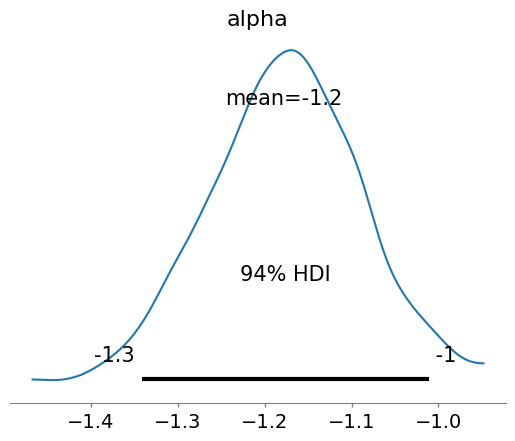

In [11]:
az.plot_posterior(
    trace,
    var_names=["alpha"]
)

plt.show()

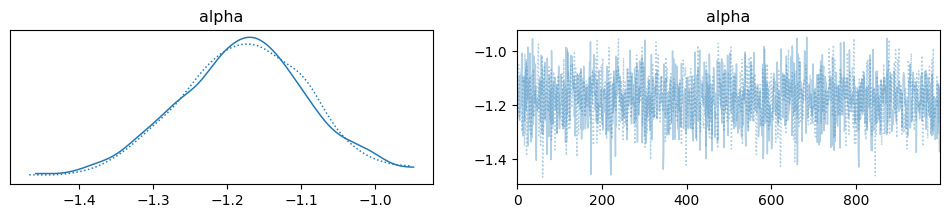

In [12]:
az.plot_trace(
    trace,
    var_names=["alpha"]
)

plt.show()

## Bayesian Modeling Interpretation

The Bayesian logistic regression model estimates the probability of credit default while explicitly accounting for uncertainty in parameter estimation.

Unlike traditional logistic regression, Bayesian inference provides posterior distributions for model parameters, allowing probabilistic interpretation of financial risk.

The posterior plots and trace diagnostics help evaluate uncertainty, parameter stability, and convergence behavior during MCMC sampling.